# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 6. modell **Inception-v3** modell teljes tanítással történő tesztelése

#### A Inception-v3 modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

🧠 Inception-v3 – Few-shot Fine-tune – 1–5. BLOKK

✅ 1. Telepítés, importálás, GPU ellenőrzés

In [ ]:
!pip install -q timm torchvision scikit-learn matplotlib tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, time, random
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, top_k_accuracy_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️ GPU elérhetőség:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.5 MB/s eta 0:00:00
🖥️ GPU elérhetőség: cuda


✅ 2. Google Drive csatolás, adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')
diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok kibontva:", extract_path)


Mounted at /content/drive
✅ Adatok kibontva: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok betöltése és részhalmazok előállítása

In [ ]:
from collections import defaultdict

# Transzformáció Inception-re optimalizálva
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Teljes és validációs / teszt halmaz
train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált mintavétel
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    per_class = total_images // len(class_indices)
    selected_indices = []

    for cls, indices in class_indices.items():
        chosen = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(chosen)

    print(f"📦 Kiválasztott képek: {len(selected_indices)}")
    return Subset(dataset, selected_indices)

subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 Kiválasztott képek: 912
📦 Kiválasztott képek: 4902
📦 Kiválasztott képek: 9918
📦 Kiválasztott képek: 24966


✅ 4. Inception-v3 modell betöltése (aux_logits=True)

In [ ]:
def get_inception_model():
    model = models.inception_v3(weights="DEFAULT", aux_logits=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
    return model.to(device)


✅ 5. Általános tanítófüggvény Inception-v3 modellhez

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes halmaz (Inception-v3)")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    model = get_inception_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, aux_outputs = model(inputs)
            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)
            loss = loss1 + 0.4 * loss2
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


🔷 BLOKK 6 – Inception-v3 @ 1k képes részhalmaz


🚀 Tanítás: 1k képes halmaz (Inception-v3)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 205MB/s] 
Epoch 1/10 - train: 100%|██████████| 15/15 [00:03<00:00,  3.88it/s]


📊 Epoch 1: Train loss=6.6375, acc=0.0121 | Val loss=4.5066, acc=0.0939


Epoch 2/10 - train: 100%|██████████| 15/15 [00:02<00:00,  5.95it/s]


📊 Epoch 2: Train loss=5.6223, acc=0.2961 | Val loss=4.2664, acc=0.2126


...

📊 Epoch 8: Train loss=1.6976, acc=0.9715 | Val loss=3.0653, acc=0.3294


Epoch 9/10 - train: 100%|██████████| 15/15 [00:02<00:00,  5.85it/s]


📊 Epoch 9: Train loss=1.3178, acc=0.9912 | Val loss=3.0018, acc=0.3365


Epoch 10/10 - train: 100%|██████████| 15/15 [00:02<00:00,  5.94it/s]


📊 Epoch 10: Train loss=0.9967, acc=0.9945 | Val loss=2.9113, acc=0.3453


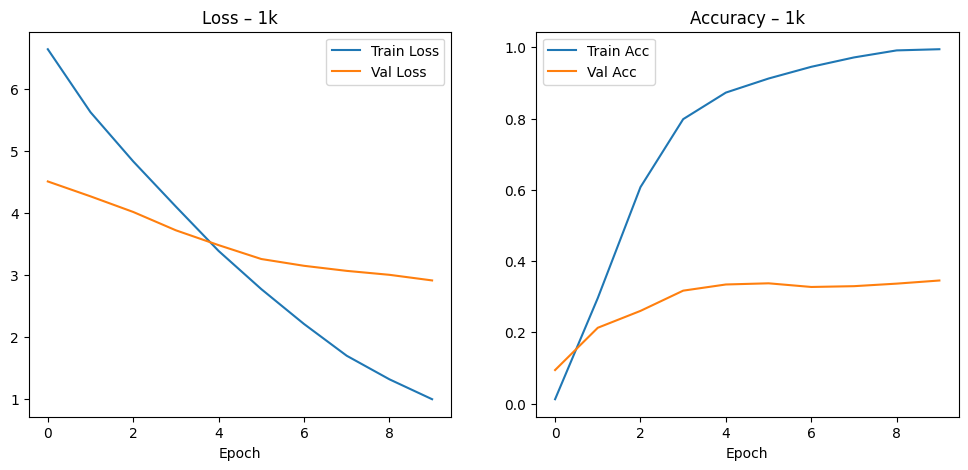

In [ ]:
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=10)

# Tanulási görbe – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés (1k modellen)

In [ ]:
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – Inception-v3 trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – Inception-v3 trained on 1k:
✅ Top-1 Accuracy:  0.3522
✅ Top-5 Accuracy:  0.6813
🎯 Precision:       0.3311
🎯 Recall:          0.3582
🎯 F1-score:        0.3217
⏱️ Inference time:  33.27 sec


🔷 BLOKK 7 – Inception-v3 @ 5k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 5k képes halmaz (Inception-v3)


Epoch 1/10 - train: 100%|██████████| 77/77 [00:11<00:00,  6.46it/s]


📊 Epoch 1: Train loss=5.7670, acc=0.1552 | Val loss=3.1262, acc=0.3519


Epoch 2/10 - train: 100%|██████████| 77/77 [00:11<00:00,  6.53it/s]


📊 Epoch 2: Train loss=3.8201, acc=0.4200 | Val loss=2.5187, acc=0.3887


...

📊 Epoch 8: Train loss=0.1671, acc=0.9922 | Val loss=2.1348, acc=0.4679


Epoch 9/10 - train: 100%|██████████| 77/77 [00:11<00:00,  6.51it/s]


📊 Epoch 9: Train loss=0.1096, acc=0.9945 | Val loss=2.1608, acc=0.4712


Epoch 10/10 - train: 100%|██████████| 77/77 [00:11<00:00,  6.53it/s]


📊 Epoch 10: Train loss=0.0738, acc=0.9965 | Val loss=2.2529, acc=0.4563


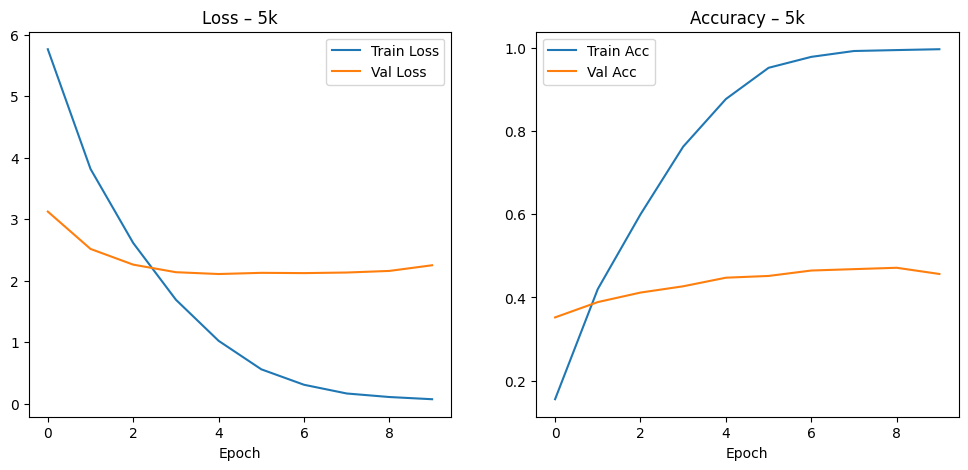

In [ ]:
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=10)

# Tanulási görbék – 5k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (5k modellen)

In [ ]:
model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – Inception-v3 trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – Inception-v3 trained on 5k:
✅ Top-1 Accuracy:  0.4604
✅ Top-5 Accuracy:  0.7875
🎯 Precision:       0.4472
🎯 Recall:          0.4857
🎯 F1-score:        0.4472
⏱️ Inference time:  33.30 sec


🔷 BLOKK 8 – Inception-v3 @ 10k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 10k képes halmaz (Inception-v3)


Epoch 1/10 - train: 100%|██████████| 155/155 [00:23<00:00,  6.60it/s]


📊 Epoch 1: Train loss=5.0005, acc=0.2447 | Val loss=2.5917, acc=0.3494


Epoch 2/10 - train: 100%|██████████| 155/155 [00:23<00:00,  6.51it/s]


📊 Epoch 2: Train loss=2.9755, acc=0.4954 | Val loss=2.0496, acc=0.4688


...

📊 Epoch 8: Train loss=0.1080, acc=0.9897 | Val loss=2.2115, acc=0.4993


Epoch 9/10 - train: 100%|██████████| 155/155 [00:23<00:00,  6.58it/s]


📊 Epoch 9: Train loss=0.0804, acc=0.9924 | Val loss=2.3126, acc=0.4929


Epoch 10/10 - train: 100%|██████████| 155/155 [00:23<00:00,  6.58it/s]


📊 Epoch 10: Train loss=0.0715, acc=0.9920 | Val loss=2.3683, acc=0.4907


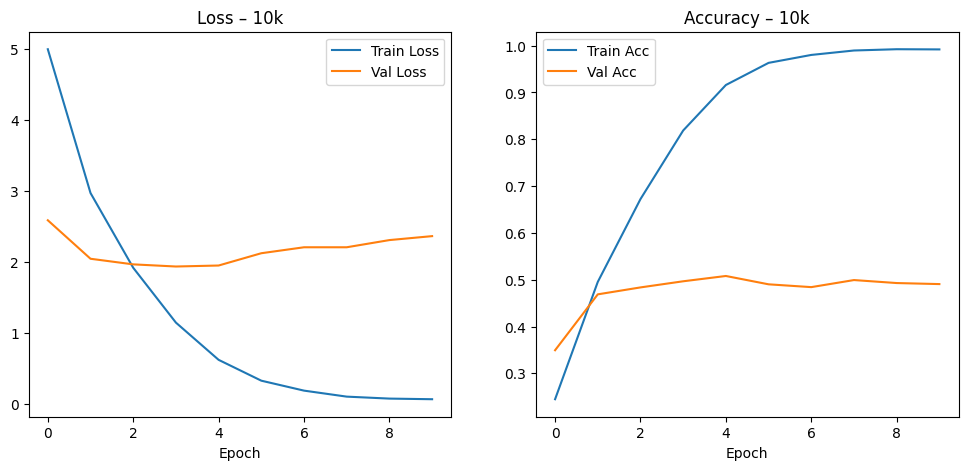

In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=10)

# Tanulási görbék – 10k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (10k modellen)

In [ ]:
model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – Inception-v3 trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – Inception-v3 trained on 10k:
✅ Top-1 Accuracy:  0.4893
✅ Top-5 Accuracy:  0.7991
🎯 Precision:       0.4671
🎯 Recall:          0.5194
🎯 F1-score:        0.4733
⏱️ Inference time:  33.68 sec


🔷 BLOKK 9 – Inception-v3 @ 25k képes részhalmaz

🚀 Tanítás + tanulási görbék


🚀 Tanítás: 25k képes halmaz (Inception-v3)


Epoch 1/10 - train: 100%|██████████| 391/391 [00:58<00:00,  6.65it/s]


📊 Epoch 1: Train loss=3.9352, acc=0.3550 | Val loss=1.9708, acc=0.4605


Epoch 2/10 - train: 100%|██████████| 391/391 [00:58<00:00,  6.66it/s]


📊 Epoch 2: Train loss=2.2384, acc=0.5855 | Val loss=1.8083, acc=0.5075


...

📊 Epoch 8: Train loss=0.1772, acc=0.9678 | Val loss=2.0709, acc=0.5633


Epoch 9/10 - train: 100%|██████████| 391/391 [00:58<00:00,  6.65it/s]


📊 Epoch 9: Train loss=0.1536, acc=0.9729 | Val loss=2.1089, acc=0.5676


Epoch 10/10 - train: 100%|██████████| 391/391 [00:58<00:00,  6.66it/s]


📊 Epoch 10: Train loss=0.1536, acc=0.9708 | Val loss=2.1756, acc=0.5607


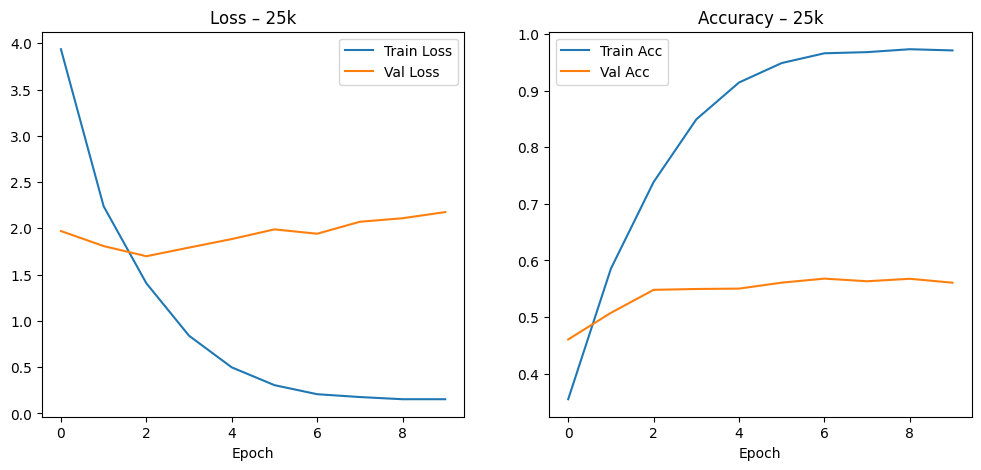

In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=10)

# Tanulási görbék – 25k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()


🧪 Tesztelés – Metrikák (25k modellen)

In [ ]:
model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – Inception-v3 trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Metrikák – Inception-v3 trained on 25k:
✅ Top-1 Accuracy:  0.5602
✅ Top-5 Accuracy:  0.8439
🎯 Precision:       0.5255
🎯 Recall:          0.5823
🎯 F1-score:        0.5337
⏱️ Inference time:  33.46 sec


🔷 BLOKK 10 – 📊 Összevont tanulási görbék (Train / Val – Acc és Loss)

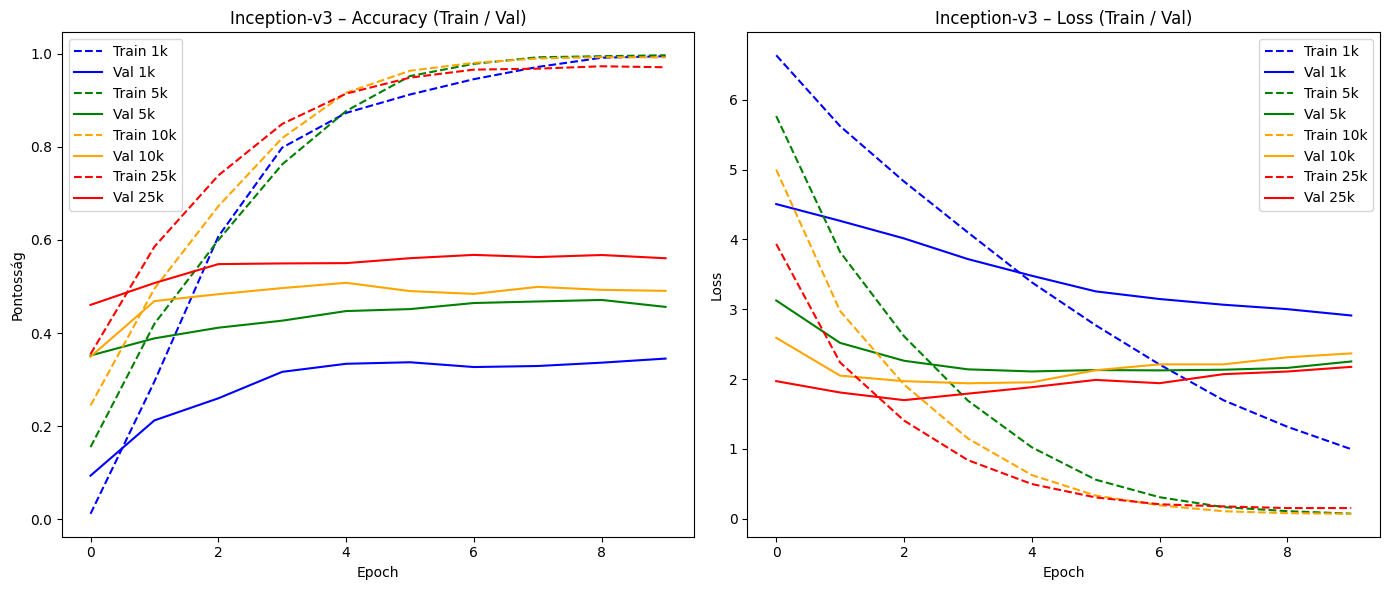

In [ ]:
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k, label="Val 1k", color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k, label="Val 5k", color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k, label="Val 10k", color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k, label="Val 25k", color='red')
plt.title("Inception-v3 – Accuracy (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k, label="Val 1k", color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k, label="Val 5k", color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k, label="Val 10k", color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k, label="Val 25k", color='red')
plt.title("Inception-v3 – Loss (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


🔷 BLOKK 11 – 🟦 2×2 Confusion Matrix Montázs (Mini)

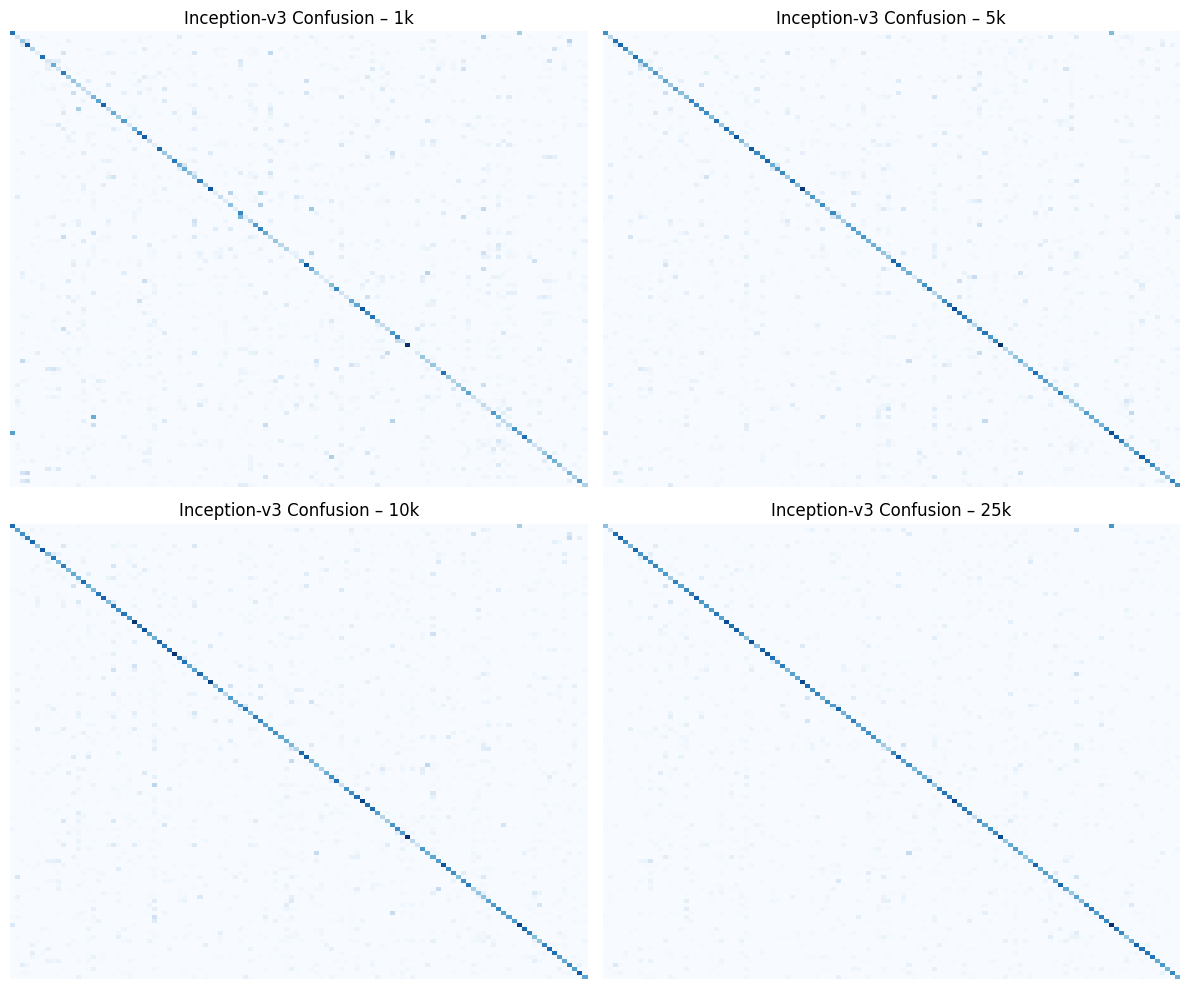

In [ ]:
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"Inception-v3 Confusion – {title}")

plt.tight_layout()
plt.show()
